In [1]:
import torch, os, sys

print("=== GPU Check ===")
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU count      : {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {p.name} | VRAM: {p.total_memory/1e9:.1f} GB")

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Primary device : {DEVICE}")


=== GPU Check ===
CUDA available : True
GPU count      : 2
  GPU 0: Tesla T4 | VRAM: 15.6 GB
  GPU 1: Tesla T4 | VRAM: 15.6 GB
Primary device : cuda:0


In [2]:
import subprocess, sys
for pkg in ["timm", "einops", "huggingface_hub", "seaborn"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
print("Dependencies installed ✓")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 82.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

Dependencies installed ✓


In [3]:
import os

BASE_DIR    = "/kaggle/working"
DATA_ROOT   = "/kaggle/input/datasets/adham7elmy/faceforencispp-extracted-frames"
CACHE_DIR   = f"{BASE_DIR}/cache"
AGDF_DIR    = f"{BASE_DIR}/agdf"
RESULTS_DIR = f"{BASE_DIR}/results"
REPO_DIR    = f"{BASE_DIR}/GenConViT"
WEIGHT_DIR  = f"{BASE_DIR}/weights"

for d in [CACHE_DIR, AGDF_DIR, RESULTS_DIR, WEIGHT_DIR]:
    os.makedirs(d, exist_ok=True)

print("Directories ready.")
print(f"Dataset exists: {os.path.exists(DATA_ROOT)}")
if os.path.exists(DATA_ROOT):
    print("Dataset contents:", os.listdir(DATA_ROOT)[:8])


Directories ready.
Dataset exists: True
Dataset contents: ['fake', 'real']


In [4]:
import os, sys

if not os.path.exists(REPO_DIR):
    os.system(f"git clone --depth 1 https://github.com/erprogs/GenConViT.git {REPO_DIR}")
else:
    print("Repo already cloned.")

sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)   # CRITICAL: config.yaml uses relative path
print("Repo ready. cwd:", os.getcwd())


Cloning into '/kaggle/working/GenConViT'...


Repo ready. cwd: /kaggle/working/GenConViT


In [5]:
from huggingface_hub import hf_hub_download
import os

for fname in ["genconvit_ed_inference.pth", "genconvit_vae_inference.pth"]:
    dest = f"{WEIGHT_DIR}/{fname}"
    if not os.path.exists(dest):
        print(f"Downloading {fname}...")
        src = hf_hub_download(repo_id="Deressa/GenConViT", filename=fname)
        os.system(f'cp "{src}" "{dest}"')
        print(f"  Saved -> {dest}")
    else:
        print(f"  {fname} already exists.")


genconvit_ed_inference.pth:   0%|          | 0.00/238M [00:00<?, ?B/s]

  Saved -> /kaggle/working/weights/genconvit_ed_inference.pth


genconvit_vae_inference.pth:   0%|          | 0.00/2.78G [00:00<?, ?B/s]

  Saved -> /kaggle/working/weights/genconvit_vae_inference.pth


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# GenConViT — Complete Fixed Loader v9
# ═══════════════════════════════════════════════════════════════════════════

import os, sys, re, torch, torch.nn as nn, inspect, timm, importlib
from collections import defaultdict

DEVICE     = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
REPO_DIR   = "/kaggle/working/GenConViT"
WEIGHT_DIR = "/kaggle/working/weights"

config = {
    "model": {
        "backbone":    "convnext_tiny",
        "embedder":    "swin_tiny_patch4_window7_224",
        "latent_dims": 12544,
    },
    "batch_size": 32, "epoch": 1, "learning_rate": 0.0001,
    "weight_decay": 0.0001, "num_classes": 2,
    "img_size": 224, "min_val_loss": 10000,
}

# ───────────────────────────────────────────────────────────────────────────
# STEP 1 — Reload swin; wrap __init__ only to absorb device=/dtype= kwargs
# ───────────────────────────────────────────────────────────────────────────
_swin_mod       = importlib.reload(importlib.import_module("timm.models.swin_transformer"))
PatchMerging    = _swin_mod.PatchMerging
_sig_params     = list(inspect.signature(PatchMerging.__init__).parameters.keys())
_HAS_OUT_DIM    = "out_dim" in _sig_params
_TRUE_ORIG_INIT = PatchMerging.__init__

print(f"[inspect] timm {timm.__version__}  has_out_dim={_HAS_OUT_DIM}")

if _HAS_OUT_DIM:
    def _kwargs_safe_init(self, dim, out_dim, norm_layer=nn.LayerNorm, **kwargs):
        _TRUE_ORIG_INIT(self, dim, out_dim, norm_layer=norm_layer, **kwargs)
else:
    def _kwargs_safe_init(self, dim, norm_layer=nn.LayerNorm, **kwargs):
        _TRUE_ORIG_INIT(self, dim, norm_layer=norm_layer, **kwargs)

PatchMerging.__init__ = _kwargs_safe_init
print("[patch] PatchMerging.__init__: kwargs-safe only")

# ───────────────────────────────────────────────────────────────────────────
# STEP 2 — Imports
# ───────────────────────────────────────────────────────────────────────────
os.chdir(REPO_DIR)
for k in list(sys.modules.keys()):
    if any(x in k for x in ["genconvit", "model_embedder", "config", "model."]):
        del sys.modules[k]

import yaml
with open("model/config.yaml", "w") as f:
    yaml.dump(config, f)
print("config.yaml written:", config["model"])

from model.genconvit_ed  import GenConViTED
from model.genconvit_vae import GenConViTVAE
print("Imports OK ✓")

# ───────────────────────────────────────────────────────────────────────────
# HELPERS
# ───────────────────────────────────────────────────────────────────────────
_BUFFER_SUFFIXES = {"attn.relative_position_index", "attn_mask"}

def _is_buffer(k):
    return any(k.endswith(s) for s in _BUFFER_SUFFIXES)

def _group(k):  return k.split(".")[0]
def _sec(t):    print(f"\n{'═'*72}\n  {t}\n{'═'*72}")
def _sub(t):    print(f"\n{'─'*72}\n  {t}\n{'─'*72}")

def _build_remap(ckpt_sd, model_sd):
    remap = {}
    for k in ckpt_sd:
        new_k = k

        # A) head key rename
        if (k.endswith(".head.weight") or k.endswith(".head.bias")) \
                and k not in model_sd:
            candidate = k.rsplit(".", 1)[0] + ".fc." + k.rsplit(".", 1)[1]
            if candidate in model_sd:
                new_k = candidate

        # B) Swin downsample layer-index shift +1
        if "downsample" in new_k:
            def _shift(m):
                return f"layers.{int(m.group(1)) + 1}.downsample"
            shifted = re.sub(r"layers\.(\d+)\.downsample", _shift, new_k)
            if shifted != new_k and shifted in model_sd:
                new_k = shifted

        if new_k != k:
            remap[k] = new_k

    return remap

# ───────────────────────────────────────────────────────────────────────────
# LOADER
# ───────────────────────────────────────────────────────────────────────────
def load_genconvit(ModelClass, weight_path, device, cfg):
    _sec(f"Loading {ModelClass.__name__}  ←  {os.path.basename(weight_path)}")

    ckpt = torch.load(weight_path, map_location="cpu", weights_only=False)
    sd   = ckpt.get("state_dict", ckpt) if isinstance(ckpt, dict) else ckpt

    model    = ModelClass(cfg)
    model_sd = model.state_dict()

    print(f"  .pth  keys : {len(sd)}")
    print(f"  model keys : {len(model_sd)}")

    remap = _build_remap(sd, model_sd)
    if remap:
        _sub(f"Key remaps ({len(remap)})")
        for old, new in sorted(remap.items()):
            print(f"  {old}\n  → {new}\n")
    sd = {remap.get(k, k): v for k, v in sd.items()}

    ck_keys, mo_keys = set(sd.keys()), set(model_sd.keys())
    matched, shape_err, only_ckpt, only_model = {}, {}, {}, {}

    for k in sorted(ck_keys):
        if k in mo_keys:
            cs, ms = tuple(sd[k].shape), tuple(model_sd[k].shape)
            if cs == ms:  matched[k]   = sd[k]
            else:         shape_err[k] = (cs, ms)
        else:
            only_ckpt[k] = tuple(sd[k].shape)

    for k in sorted(mo_keys):
        if k not in ck_keys and k not in matched:
            only_model[k] = tuple(model_sd[k].shape)

    buffers    = {k: v for k, v in only_ckpt.items() if _is_buffer(k)}
    unexpected = {k: v for k, v in only_ckpt.items() if not _is_buffer(k)}

    _sub("KEY MATCH SUMMARY")
    print(f"  ✓ Exact matches      : {len(matched)}")
    print(f"  ✗ Shape mismatches   : {len(shape_err)}")
    print(f"  ⚠ In .pth only       : {len(only_ckpt)}")
    print(f"      Known buffers     : {len(buffers)}  (safely skipped)")
    print(f"      Unexpected        : {len(unexpected)}")
    print(f"  ⚠ In model only      : {len(only_model)}")

    if shape_err:
        _sub(f"SHAPE MISMATCHES ({len(shape_err)})")
        for k, (cs, ms) in sorted(shape_err.items()):
            print(f"  ✗ {k}\n       .pth={cs}  model={ms}")

    if unexpected:
        _sub(f"IN .PTH ONLY — unexpected ({len(unexpected)})")
        for k, sh in sorted(unexpected.items()):
            print(f"  ⚠ {k}  shape={sh}")

    if only_model:
        _sub(f"IN MODEL ONLY — not in .pth ({len(only_model)})")
        for k, sh in sorted(only_model.items()):
            print(f"  ⚠ {k}  shape={sh}")

    _sub("PER-GROUP COVERAGE")
    g_total, g_match, g_skip = defaultdict(int), defaultdict(int), defaultdict(list)
    for k in mo_keys:
        g = _group(k)
        g_total[g] += 1
        if k in matched: g_match[g] += 1
        else:            g_skip[g].append(k)

    print(f"  {'Group':<32} {'Matched':>8} {'Total':>8} {'Pct':>8}")
    print(f"  {'-'*32} {'-'*8} {'-'*8} {'-'*8}")
    for g in sorted(g_total):
        t, m = g_total[g], g_match[g]
        pct  = 100.0 * m / t if t else 0
        flag = "✓" if pct == 100 else ("⚠" if pct >= 90 else "✗")
        print(f"  {flag} {g:<30} {m:>8} {t:>8} {pct:>7.1f}%")

    for g in sorted(g_skip):
        if g_skip[g]:
            print(f"\n  Skipped in '{g}':")
            for k in sorted(g_skip[g]):
                if k in shape_err:
                    cs, ms = shape_err[k]
                    print(f"    ✗ {k}  [shape mismatch]  pth={cs} model={ms}")
                else:
                    print(f"    ⚠ {k}  [not in .pth]  model={tuple(model_sd[k].shape)}")

    _sub("LOADING WEIGHTS")
    merged = dict(model_sd)
    merged.update(matched)
    model.load_state_dict(merged, strict=False)
    print(f"  Loaded {len(matched)} tensors into model")

    _sub("TRAINABLE WEIGHT COVERAGE")
    trainable_ckpt    = {k for k in sd if not _is_buffer(k)}
    trainable_matched = {k for k in matched if k in trainable_ckpt}
    coverage          = len(trainable_matched) / len(trainable_ckpt) if trainable_ckpt else 0

    print(f"  .pth trainable keys : {len(trainable_ckpt)}")
    print(f"  Matched trainable   : {len(trainable_matched)}")
    print(f"  Coverage            : {100*coverage:.2f}%")

    unmatched = trainable_ckpt - set(matched.keys())
    if unmatched:
        print(f"\n  Unmatched trainable ({len(unmatched)}):")
        for k in sorted(unmatched):
            if k in shape_err:
                cs, ms = shape_err[k]
                print(f"    ✗ {k}  [shape mismatch]  pth={cs}  model={ms}")
            else:
                print(f"    ⚠ {k}  [key not in model]  pth={tuple(sd[k].shape)}")

    benign = {k for k in unmatched
              if re.search(r"layers\.[03]\.downsample", k)}
    real_failures = unmatched - benign

    if real_failures:
        raise RuntimeError(
            f"CRITICAL: {len(real_failures)} non-benign trainable keys unmatched:\n"
            + "\n".join(f"  {k}" for k in sorted(real_failures))
        )
    elif benign:
        print(f"\n  ⚠ {len(benign)} benign structural orphans (layer-0/layer-3 downsample)")
        print(f"    All classification-path weights fully loaded. ✓")
    else:
        print(f"\n  ✓ 100% trainable coverage — all weights loaded correctly.")

    return model.to(device).eval()

# ───────────────────────────────────────────────────────────────────────────
# POST-LOAD: value verification
# ───────────────────────────────────────────────────────────────────────────
def verify_values(model, weight_path, name):
    _sec(f"VALUE VERIFICATION — {name}")
    ckpt = torch.load(weight_path, map_location="cpu", weights_only=False)
    sd   = ckpt.get("state_dict", ckpt) if isinstance(ckpt, dict) else ckpt
    remap = _build_remap(sd, model.state_dict())
    sd    = {remap.get(k, k): v for k, v in sd.items()}
    msd   = model.state_dict()

    n_ok, n_bad, worst = 0, 0, 0.0
    for k, v_m in msd.items():
        if k not in sd or sd[k].shape != v_m.shape:
            continue
        # ── FIX: bring .pth tensor to same device as model tensor ──
        diff  = (v_m.float() - sd[k].to(v_m.device).float()).abs().max().item()
        worst = max(worst, diff)
        n_ok += 1
        if diff > 1e-5:
            n_bad += 1
            print(f"  ⚠ VALUE MISMATCH  {k}  max_diff={diff:.6f}")

    if n_bad == 0:
        print(f"  ✓ All {n_ok} tensors match .pth exactly  (worst diff = {worst:.2e})")
    else:
        print(f"  ✗ {n_bad}/{n_ok} tensors differ from .pth values!")

# ───────────────────────────────────────────────────────────────────────────
# POST-LOAD: forward pass sanity
# ───────────────────────────────────────────────────────────────────────────
def forward_sanity(net_ed, net_vae, device):
    _sec("FORWARD PASS SANITY")
    dummy = torch.randn(2, 3, 224, 224).to(device)
    with torch.no_grad():
        o_ed         = net_ed(dummy)
        o_vae, recon = net_vae(dummy)

    print(f"  ED  logits : {tuple(o_ed.shape)}   (expect (2,2))")
    print(f"  VAE logits : {tuple(o_vae.shape)}  (expect (2,2))")
    print(f"  VAE recon  : {tuple(recon.shape)}  (expect (2,3,112,112))")

    ed_sm  = torch.softmax(o_ed,  dim=1)
    vae_sm = torch.softmax(o_vae, dim=1)
    for i in range(2):
        ens = ((ed_sm[i] + vae_sm[i]) / 2).tolist()
        print(f"  Sample {i}  ED={[f'{x:.4f}' for x in ed_sm[i].tolist()]}  "
              f"VAE={[f'{x:.4f}' for x in vae_sm[i].tolist()]}  "
              f"Ensemble={[f'{x:.4f}' for x in ens]}")

    assert (ed_sm.sum(1)  - 1).abs().max() < 1e-4, "ED softmax doesn't sum to 1"
    assert (vae_sm.sum(1) - 1).abs().max() < 1e-4, "VAE softmax doesn't sum to 1"
    print("\n  ✓ Softmax rows sum to 1.0 — outputs are valid probabilities.")

# ───────────────────────────────────────────────────────────────────────────
# RUN
# ───────────────────────────────────────────────────────────────────────────
net_ed = load_genconvit(
    GenConViTED,
    f"{WEIGHT_DIR}/genconvit_ed_inference.pth",
    DEVICE, config,
)

net_vae = load_genconvit(
    GenConViTVAE,
    f"{WEIGHT_DIR}/genconvit_vae_inference.pth",
    DEVICE, config,
)

for p in net_ed.parameters():  p.requires_grad_(False)
for p in net_vae.parameters(): p.requires_grad_(False)

verify_values(net_ed,  f"{WEIGHT_DIR}/genconvit_ed_inference.pth",  "GenConViTED")
verify_values(net_vae, f"{WEIGHT_DIR}/genconvit_vae_inference.pth", "GenConViTVAE")

forward_sanity(net_ed, net_vae, DEVICE)
print("\n✓ GenConViT fully loaded and verified.")

/usr/local/lib/python3.12/dist-packages/timm/models/swin_transformer.py:1169: UserWarning: Overwriting swin_tiny_patch4_window7_224 in registry with timm.models.swin_transformer.swin_tiny_patch4_window7_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/usr/local/lib/python3.12/dist-packages/timm/models/swin_transformer.py:1178: UserWarning: Overwriting swin_small_patch4_window7_224 in registry with timm.models.swin_transformer.swin_small_patch4_window7_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/usr/local/lib/python3.12/dist-packages/timm/models/swin_transformer.py:1187: UserWarning: Overwriting swin_base_patch4_window7_224 in registry with timm.models.swin_transformer.swin_base_patch4_window7_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.

[inspect] timm 1.0.26  has_out_dim=True
[patch] PatchMerging.__init__: kwargs-safe only
config.yaml written: {'backbone': 'convnext_tiny', 'embedder': 'swin_tiny_patch4_window7_224', 'latent_dims': 12544}
Imports OK ✓

════════════════════════════════════════════════════════════════════════
  Loading GenConViTED  ←  genconvit_ed_inference.pth
════════════════════════════════════════════════════════════════════════


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  .pth  keys : 588
  model keys : 554

────────────────────────────────────────────────────────────────────────
  Key remaps (22)
────────────────────────────────────────────────────────────────────────
  backbone.patch_embed.backbone.head.bias
  → backbone.patch_embed.backbone.head.fc.bias

  backbone.patch_embed.backbone.head.weight
  → backbone.patch_embed.backbone.head.fc.weight

  backbone.patch_embed.backbone.layers.0.downsample.norm.bias
  → backbone.patch_embed.backbone.layers.1.downsample.norm.bias

  backbone.patch_embed.backbone.layers.0.downsample.norm.weight
  → backbone.patch_embed.backbone.layers.1.downsample.norm.weight

  backbone.patch_embed.backbone.layers.0.downsample.reduction.weight
  → backbone.patch_embed.backbone.layers.1.downsample.reduction.weight

  backbone.patch_embed.backbone.layers.1.downsample.norm.bias
  → backbone.patch_embed.backbone.layers.2.downsample.norm.bias

  backbone.patch_embed.backbone.layers.1.downsample.norm.weight
  → backbone.patch_embe

In [7]:
# ── FIXED: real/ folder uses plain numeric IDs directly under real/
# ── FIXED: Added FaceShifter to MANIP_TYPES (5th manipulation type present in dataset)
import os, glob, pandas as pd

print("Scanning dataset:", DATA_ROOT)

for root, dirs, files in os.walk(DATA_ROOT):
    depth = root.replace(DATA_ROOT, "").count(os.sep)
    if depth > 2: continue
    imgs = [f for f in files if f.lower().endswith((".jpg", ".png", ".jpeg"))]
    if imgs or depth <= 1:
        print("  " * depth + os.path.basename(root) + f"/  [{len(imgs)} imgs, {len(dirs)} dirs]")

all_imgs = []
for ext in ["jpg", "jpeg", "png"]:
    all_imgs += glob.glob(f"{DATA_ROOT}/**/*.{ext}", recursive=True)
print(f"\nTotal images found: {len(all_imgs)}")
if all_imgs:
    print("Sample paths:")
    for p in all_imgs[:3]: print(" ", p)

Scanning dataset: /kaggle/input/datasets/adham7elmy/faceforencispp-extracted-frames
faceforencispp-extracted-frames/  [0 imgs, 2 dirs]
  fake/  [0 imgs, 5 dirs]
  real/  [0 imgs, 999 dirs]
    437/  [32 imgs, 0 dirs]
    515/  [32 imgs, 0 dirs]
    248/  [32 imgs, 0 dirs]
    625/  [32 imgs, 0 dirs]
    843/  [32 imgs, 0 dirs]
    135/  [32 imgs, 0 dirs]
    479/  [32 imgs, 0 dirs]
    183/  [32 imgs, 0 dirs]
    973/  [32 imgs, 0 dirs]
    768/  [32 imgs, 0 dirs]
    642/  [32 imgs, 0 dirs]
    057/  [32 imgs, 0 dirs]
    313/  [32 imgs, 0 dirs]
    795/  [32 imgs, 0 dirs]
    600/  [32 imgs, 0 dirs]
    086/  [32 imgs, 0 dirs]
    466/  [32 imgs, 0 dirs]
    494/  [32 imgs, 0 dirs]
    199/  [32 imgs, 0 dirs]
    480/  [32 imgs, 0 dirs]
    121/  [32 imgs, 0 dirs]
    823/  [32 imgs, 0 dirs]
    856/  [32 imgs, 0 dirs]
    695/  [32 imgs, 0 dirs]
    061/  [32 imgs, 0 dirs]
    988/  [32 imgs, 0 dirs]
    262/  [32 imgs, 0 dirs]
    653/  [32 imgs, 0 dirs]
    849/  [32 imgs, 0 dirs]

In [8]:
import pandas as pd, os, glob

records = []
# FIX 1: Added FaceShifter — it's a 5th manipulation type present in the dataset
MANIP_TYPES = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures", "FaceShifter"]
IMG_EXTS    = (".jpg", ".jpeg", ".png")

for root, dirs, files in os.walk(DATA_ROOT):
    imgs = [f for f in files if f.lower().endswith(IMG_EXTS)]
    if not imgs:
        continue

    path_lower = root.lower()

    # Determine label
    label = -1
    manip = ""

    # Check for fake — match against known manipulation folder names
    for mt in MANIP_TYPES:
        if mt.lower() in path_lower:
            label = 1
            manip = mt
            break

    # FIX 2: Real images are directly under DATA_ROOT/real/<numeric_id>/
    # The old code looked for "original_sequences", "youtube", "actors" — none exist here.
    # New approach: if the path starts with the real/ subdirectory, it's real.
    if label == -1:
        real_prefix = os.path.join(DATA_ROOT, "real") + os.sep
        if root.startswith(real_prefix):
            label = 0
            manip = "real"

    if label == -1:
        continue  # skip anything unrecognised

    for f in imgs:
        records.append({
            "path":         os.path.join(root, f),
            "label":        label,
            "manipulation": manip,
        })

df = pd.DataFrame(records).drop_duplicates("path").reset_index(drop=True)

print(f"Total frames: {len(df)}")
print(df.groupby(["label", "manipulation"]).size().reset_index(name="count").to_string(index=False))

n_real = (df.label == 0).sum()
n_fake = (df.label == 1).sum()
print(f"\nReal: {n_real}  |  Fake: {n_fake}")

if n_real == 0 or n_fake == 0:
    raise RuntimeError(f"⚠️ Still only one class! Real={n_real}, Fake={n_fake}. Check DATA_ROOT.")
else:
    print("✓ Both classes found")

CSV_PATH = f"{BASE_DIR}/labels.csv"
df.to_csv(CSV_PATH, index=False)
print(f"Saved: {CSV_PATH}")

Total frames: 191550
 label   manipulation  count
     0           real  31949
     1      Deepfakes  31843
     1      Face2Face  31949
     1    FaceShifter  31924
     1       FaceSwap  31954
     1 NeuralTextures  31931

Real: 31949  |  Fake: 159601
✓ Both classes found
Saved: /kaggle/working/labels.csv


In [9]:
import torch, pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

class DeepfakeFrameDataset(Dataset):
    def __init__(self, df, transform=None, max_per_class=None, seed=42):
        if max_per_class:
            real = df[df.label == 0].sample(
                min(max_per_class, (df.label == 0).sum()), random_state=seed)
            fake = df[df.label == 1].sample(
                min(max_per_class, (df.label == 1).sum()), random_state=seed)
            df = pd.concat([real, fake]).reset_index(drop=True)
        self.df        = df.reset_index(drop=True)
        self.transform = transform or TRANSFORM

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row["path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224))
        return self.transform(img), int(row["label"]), str(row["manipulation"])

# FIX: now that real frames exist (~32k), max_per_class=5000 gives a balanced 5k/5k split
MAX_PER_CLASS = 5000
dataset      = DeepfakeFrameDataset(df, max_per_class=MAX_PER_CLASS)
cache_loader = DataLoader(dataset, batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)

n_real = sum(1 for _, lbl, _ in dataset if lbl == 0)
n_fake = sum(1 for _, lbl, _ in dataset if lbl == 1)
print(f"Dataset: {len(dataset)} frames  |  Real: {n_real}  Fake: {n_fake}")
print(f"Batches: {len(cache_loader)}")

Dataset: 10000 frames  |  Real: 5000  Fake: 5000
Batches: 157


In [10]:
import numpy as np, torch, os
from tqdm.notebook import tqdm

CACHE_FILE = f"{CACHE_DIR}/predictions.npz"

# FIX: delete stale cache that was built with 0 real frames
if os.path.exists(CACHE_FILE):
    cached = np.load(CACHE_FILE, allow_pickle=True)
    cached_labels = cached["labels"]
    if (cached_labels == 0).sum() == 0:
        print("⚠️  Stale cache detected (0 real frames) — deleting and rebuilding...")
        os.remove(CACHE_FILE)
    else:
        print("Cache found and valid — loading...")
        pred_ed_cache  = cached["pred_ed"]
        pred_vae_cache = cached["pred_vae"]
        labels_cache   = cached["labels"]
        manips_cache   = cached["manips"]

if not os.path.exists(CACHE_FILE):
    print("Running feature extraction (one-time ~10-20 min)...")
    net_ed.eval()
    net_vae.eval()
    all_ed, all_vae, all_lbl, all_mnp = [], [], [], []

    with torch.no_grad():
        for imgs, labels, manips in tqdm(cache_loader, desc="Caching"):
            imgs = imgs.to(DEVICE)
            o_ed = net_ed(imgs)
            o_vae, _ = net_vae(imgs)
            all_ed.append(torch.softmax(o_ed,  dim=1).cpu().numpy())
            all_vae.append(torch.softmax(o_vae, dim=1).cpu().numpy())
            all_lbl.extend(labels.numpy())
            all_mnp.extend(list(manips))

    pred_ed_cache  = np.concatenate(all_ed,  axis=0)
    pred_vae_cache = np.concatenate(all_vae, axis=0)
    labels_cache   = np.array(all_lbl, dtype=np.int64)
    manips_cache   = np.array(all_mnp)
    np.savez(CACHE_FILE, pred_ed=pred_ed_cache, pred_vae=pred_vae_cache,
             labels=labels_cache, manips=manips_cache)
    print("Cache saved.")

# FIX: GenConViT's native output is col0=P(FAKE), col1=P(REAL) — see model/pred_func.py
# (real_or_fake = {0:"REAL",1:"FAKE"}[pred ^ 1]). Our labels use the opposite
# (0=real, 1=fake), which is what caused the below-random scores. Swap columns
# once here so every downstream cell sees col0=P(real), col1=P(fake).
pred_ed_cache  = pred_ed_cache[:,  [1, 0]]
pred_vae_cache = pred_vae_cache[:, [1, 0]]

print(f"Cached: {len(labels_cache)} frames")
print(f"Real  : {(labels_cache==0).sum()}  |  Fake: {(labels_cache==1).sum()}")
print(f"Manips: {dict(zip(*np.unique(manips_cache, return_counts=True)))}")

if (labels_cache == 0).sum() == 0 or (labels_cache == 1).sum() == 0:
    raise ValueError("Only one class in cache! Dataset scan failed.")
print("✓ Both classes present in cache")

p_fake_real = pred_ed_cache[labels_cache == 0, 1].mean()
p_fake_fake = pred_ed_cache[labels_cache == 1, 1].mean()
print(f"✓ Orientation check — mean P(fake): real={p_fake_real:.4f}  fake={p_fake_fake:.4f}")
assert p_fake_fake > p_fake_real, "Still inverted — stop and recheck."

Running feature extraction (one-time ~10-20 min)...


Caching:   0%|          | 0/157 [00:00<?, ?it/s]

Cache saved.
Cached: 10000 frames
Real  : 5000  |  Fake: 5000
Manips: {np.str_('Deepfakes'): np.int64(1011), np.str_('Face2Face'): np.int64(943), np.str_('FaceShifter'): np.int64(1043), np.str_('FaceSwap'): np.int64(1041), np.str_('NeuralTextures'): np.int64(962), np.str_('real'): np.int64(5000)}
✓ Both classes present in cache
✓ Orientation check — mean P(fake): real=0.5906  fake=0.8505


In [11]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.utils.data import Dataset, DataLoader, random_split
import torch

class CachedPredDataset(Dataset):
    def __init__(self, pred_ed, pred_vae, labels, manips=None):
        self.pred_ed  = torch.FloatTensor(pred_ed)
        self.pred_vae = torch.FloatTensor(pred_vae)
        self.labels   = torch.LongTensor(labels)
        self.manips   = np.array(manips) if manips is not None else np.array([""]*len(labels))
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return self.pred_ed[i], self.pred_vae[i], self.labels[i], str(self.manips[i])

full_ds = CachedPredDataset(pred_ed_cache, pred_vae_cache, labels_cache, manips_cache)
N       = len(full_ds)
n_tr, n_va = int(0.70 * N), int(0.15 * N)
n_te    = N - n_tr - n_va

train_ds, val_ds, test_ds = random_split(
    full_ds, [n_tr, n_va, n_te], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

print(f"Split  Train: {n_tr}  Val: {n_va}  Test: {n_te}")

val_lbls  = labels_cache[val_ds.indices]
test_lbls = labels_cache[test_ds.indices]
print(f"Val  — Real: {(val_lbls==0).sum()}  Fake: {(val_lbls==1).sum()}")
print(f"Test — Real: {(test_lbls==0).sum()}  Fake: {(test_lbls==1).sum()}")

# Baseline (static average ensemble)
bl_avg  = (pred_ed_cache[test_ds.indices] + pred_vae_cache[test_ds.indices]) / 2
bl_pred = np.argmax(bl_avg, axis=1)
bl_lbl  = labels_cache[test_ds.indices]
bl_acc  = accuracy_score(bl_lbl, bl_pred)
bl_f1   = f1_score(bl_lbl, bl_pred, zero_division=0)
try:    bl_auc = roc_auc_score(bl_lbl, bl_avg[:, 1])
except: bl_auc = 0.0
print(f"\nBaseline (static avg) Acc={bl_acc:.4f}  F1={bl_f1:.4f}  AUC={bl_auc:.4f}")

Split  Train: 7000  Val: 1500  Test: 1500
Val  — Real: 764  Fake: 736
Test — Real: 746  Fake: 754

Baseline (static avg) Acc=0.6327  F1=0.7098  AUC=0.7629


In [12]:
import torch, torch.nn as nn, torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma; self.alpha = alpha
    def forward(self, logits, targets):
        ce    = F.cross_entropy(logits, targets, reduction="none")
        p_t   = torch.exp(-ce)
        loss  = self.alpha * (1 - p_t) ** self.gamma * ce
        return loss.mean()

class AGDF(nn.Module):
    """
    Adaptive Gated Decision Fusion.
    input : [p_ed(2), p_vae(2), H_ed(1), H_vae(1)]  → dim=6
    output: w_ed * P_ed + w_vae * P_vae
    """
    def __init__(self, in_dim=6, hidden_dims=(256, 64), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 2), nn.Softmax(dim=1)]
        self.gate = nn.Sequential(*layers)

    @staticmethod
    def entropy(p):
        return -(p * torch.log(p.clamp(min=1e-9))).sum(dim=1, keepdim=True)

    def forward(self, p_ed, p_vae):
        h_ed  = self.entropy(p_ed)
        h_vae = self.entropy(p_vae)
        feat  = torch.cat([p_ed, p_vae, h_ed, h_vae], dim=1)  # (B, 6)
        w     = self.gate(feat)                                  # (B, 2)
        w_ed  = w[:, 0:1]; w_vae = w[:, 1:2]
        return w_ed * p_ed + w_vae * p_vae, w_ed.squeeze(1), w_vae.squeeze(1)

# Quick test
_m = AGDF()
_a = torch.softmax(torch.randn(4,2), dim=1)
_b = torch.softmax(torch.randn(4,2), dim=1)
_o, _w1, _w2 = _m(_a, _b)
print(f"AGDF output: {_o.shape}  params: {sum(p.numel() for p in _m.parameters()):,}")
print(f"Sample weights: w_ed={_w1[0].item():.3f}  w_vae={_w2[0].item():.3f}")


AGDF output: torch.Size([4, 2])  params: 19,010
Sample weights: w_ed=0.710  w_vae=0.290


In [13]:
import time, numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    all_w_ed, all_w_vae = [], []
    with torch.no_grad():
        for p_ed, p_vae, labels, _ in loader:
            p_ed, p_vae = p_ed.to(device), p_vae.to(device)
            out, w_ed, w_vae = model(p_ed, p_vae)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(out[:,1].cpu().numpy())
            all_w_ed.extend(w_ed.cpu().numpy())
            all_w_vae.extend(w_vae.cpu().numpy())
    L, P = np.array(all_labels), np.array(all_preds)
    acc  = accuracy_score(L, P)
    f1   = f1_score(L, P, zero_division=0)
    try:    auc = roc_auc_score(L, np.array(all_probs))
    except: auc = 0.0
    return {"acc": acc, "f1": f1, "auc": auc,
            "preds": P, "labels": L,
            "w_ed": np.array(all_w_ed), "w_vae": np.array(all_w_vae)}

def train_agdf(model, train_loader, val_loader, criterion, lr=1e-3,
               epochs=50, device=DEVICE, save_path=None, label="AGDF"):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    history = {"loss":[], "val_acc":[], "val_f1":[], "val_auc":[]}
    best_f1 = 0.0

    print(f"\n{'='*60}")
    print(f"  {label}  |  epochs={epochs}  |  {device}")
    print(f"{'='*60}")

    for ep in range(1, epochs+1):
        model.train(); ep_loss = 0.0; t0 = time.time()
        for p_ed, p_vae, labels, _ in train_loader:
            p_ed, p_vae, labels = p_ed.to(device), p_vae.to(device), labels.to(device)
            opt.zero_grad(set_to_none=True)
            out, _, _ = model(p_ed, p_vae)
            loss = criterion(out, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item()
        sch.step()

        m = evaluate(model, val_loader, device)
        history["loss"].append(ep_loss/len(train_loader))
        history["val_acc"].append(m["acc"])
        history["val_f1"].append(m["f1"])
        history["val_auc"].append(m["auc"])

        if ep % 10 == 0 or ep == 1:
            print(f"  Ep {ep:03d}/{epochs} | Loss={ep_loss/len(train_loader):.4f} "
                  f"| Acc={m['acc']:.4f} | F1={m['f1']:.4f} | AUC={m['auc']:.4f} | {time.time()-t0:.1f}s")

        # Always save best by F1; if F1=0 for all, save by accuracy
        score = m["f1"] if m["f1"] > 0 else m["acc"]
        if save_path and score > best_f1:
            best_f1 = score
            torch.save(model.state_dict(), save_path)

    # Fallback: if checkpoint was never saved (F1 always 0), save final
    if save_path and not os.path.exists(save_path):
        torch.save(model.state_dict(), save_path)
        print(f"  Fallback save -> {save_path}")

    print(f"  Best score: {best_f1:.4f} -> {save_path}")
    return history

print("Training helpers ready ✓")


Training helpers ready ✓


In [14]:
import os

# Exp A: AGDF + Cross-Entropy
agdf_ce  = AGDF().to(DEVICE)
hist_ce  = train_agdf(agdf_ce, train_loader, val_loader,
                       nn.CrossEntropyLoss(), lr=1e-3, epochs=50,
                       device=DEVICE, save_path=f"{AGDF_DIR}/agdf_ce_best.pth",
                       label="AGDF + CrossEntropy")

# Exp B: AGDF + Focal Loss (Main Contribution)
agdf_fl  = AGDF().to(DEVICE)
hist_fl  = train_agdf(agdf_fl, train_loader, val_loader,
                       FocalLoss(gamma=2.0, alpha=0.25), lr=1e-3, epochs=50,
                       device=DEVICE, save_path=f"{AGDF_DIR}/agdf_focal_best.pth",
                       label="AGDF + Focal Loss")

# Gamma Ablation
print("\n=== Gamma Ablation ===")
gamma_results = {}
for gamma in [0.5, 1.0, 2.0, 3.0, 5.0]:
    mg = AGDF().to(DEVICE)
    og = torch.optim.AdamW(mg.parameters(), lr=1e-3)
    cg = FocalLoss(gamma=gamma)
    for ep in range(30):
        mg.train()
        for p_ed, p_vae, labels, _ in train_loader:
            p_ed, p_vae, labels = p_ed.to(DEVICE), p_vae.to(DEVICE), labels.to(DEVICE)
            og.zero_grad(set_to_none=True)
            out, _, _ = mg(p_ed, p_vae)
            cg(out, labels).backward()
            og.step()
    m = evaluate(mg, val_loader, DEVICE)
    gamma_results[gamma] = m
    print(f"  gamma={gamma:.1f}  Acc={m['acc']:.4f}  F1={m['f1']:.4f}  AUC={m['auc']:.4f}")
    del mg; torch.cuda.empty_cache()



  AGDF + CrossEntropy  |  epochs=50  |  cuda:0
  Ep 001/50 | Loss=0.6183 | Acc=0.7013 | F1=0.7245 | AUC=0.7854 | 1.0s
  Ep 010/50 | Loss=0.6059 | Acc=0.7027 | F1=0.7198 | AUC=0.7839 | 0.3s
  Ep 020/50 | Loss=0.6055 | Acc=0.7027 | F1=0.7198 | AUC=0.7840 | 0.3s
  Ep 030/50 | Loss=0.6052 | Acc=0.7027 | F1=0.7198 | AUC=0.7838 | 0.3s
  Ep 040/50 | Loss=0.6048 | Acc=0.7027 | F1=0.7198 | AUC=0.7835 | 0.3s
  Ep 050/50 | Loss=0.6052 | Acc=0.7027 | F1=0.7198 | AUC=0.7836 | 0.3s
  Best score: 0.7245 -> /kaggle/working/agdf/agdf_ce_best.pth

  AGDF + Focal Loss  |  epochs=50  |  cuda:0
  Ep 001/50 | Loss=0.0473 | Acc=0.7020 | F1=0.7266 | AUC=0.7856 | 0.3s
  Ep 010/50 | Loss=0.0450 | Acc=0.7013 | F1=0.7200 | AUC=0.7832 | 0.3s
  Ep 020/50 | Loss=0.0447 | Acc=0.7013 | F1=0.7189 | AUC=0.7821 | 0.3s
  Ep 030/50 | Loss=0.0447 | Acc=0.7027 | F1=0.7202 | AUC=0.7820 | 0.3s
  Ep 040/50 | Loss=0.0446 | Acc=0.7027 | F1=0.7206 | AUC=0.7822 | 0.3s
  Ep 050/50 | Loss=0.0446 | Acc=0.7047 | F1=0.7226 | AUC=0.7821

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

# Load best checkpoints
agdf_ce.load_state_dict(torch.load(f"{AGDF_DIR}/agdf_ce_best.pth",    map_location=DEVICE))
agdf_fl.load_state_dict(torch.load(f"{AGDF_DIR}/agdf_focal_best.pth", map_location=DEVICE))

results = {}
for name, model in [("AGDF+CE", agdf_ce), ("AGDF+Focal", agdf_fl)]:
    r = evaluate(model, test_loader, DEVICE)
    manip_list = []
    for _, _, _, manips in test_loader: manip_list.extend(manips)
    r["manips"] = np.array(manip_list)
    results[name] = r
    print(f"\n=== {name} ===")
    print(f"  Acc={r['acc']:.4f}  F1={r['f1']:.4f}  AUC={r['auc']:.4f}")
    print(classification_report(r["labels"], r["preds"], target_names=["Real","Fake"], digits=4))



=== AGDF+CE ===
  Acc=0.6813  F1=0.7120  AUC=0.7654
              precision    recall  f1-score   support

        Real     0.7256    0.5777    0.6433       746
        Fake     0.6523    0.7838    0.7120       754

    accuracy                         0.6813      1500
   macro avg     0.6890    0.6808    0.6777      1500
weighted avg     0.6888    0.6813    0.6778      1500


=== AGDF+Focal ===
  Acc=0.6793  F1=0.7111  AUC=0.7606
              precision    recall  f1-score   support

        Real     0.7250    0.5724    0.6397       746
        Fake     0.6498    0.7851    0.7111       754

    accuracy                         0.6793      1500
   macro avg     0.6874    0.6788    0.6754      1500
weighted avg     0.6872    0.6793    0.6756      1500



In [16]:
TRAIN_MANIPS = {"Deepfakes", "Face2Face", "real"}
TEST_MANIPS  = {"FaceSwap", "NeuralTextures", "real"}

def make_lodo(keep):
    mask = np.isin(manips_cache, list(keep))
    return CachedPredDataset(pred_ed_cache[mask], pred_vae_cache[mask],
                              labels_cache[mask], manips_cache[mask])

lodo_tr = DataLoader(make_lodo(TRAIN_MANIPS), batch_size=512, shuffle=True,  num_workers=2)
lodo_te = DataLoader(make_lodo(TEST_MANIPS),  batch_size=512, shuffle=False, num_workers=2)

print(f"LODO train: {len(lodo_tr.dataset)}  test: {len(lodo_te.dataset)}")

agdf_lodo = AGDF().to(DEVICE)
train_agdf(agdf_lodo, lodo_tr, lodo_te, FocalLoss(2.0, 0.25), epochs=50,
           device=DEVICE, save_path=f"{AGDF_DIR}/agdf_lodo_best.pth", label="AGDF LODO")

agdf_lodo.load_state_dict(torch.load(f"{AGDF_DIR}/agdf_lodo_best.pth", map_location=DEVICE))
lodo_m = evaluate(agdf_lodo, lodo_te, DEVICE)

# Baseline LODO
tm = np.isin(manips_cache, list(TEST_MANIPS))
bl_lodo = np.argmax((pred_ed_cache[tm]+pred_vae_cache[tm])/2, axis=1)
bl_lodo_acc = accuracy_score(labels_cache[tm], bl_lodo)
bl_lodo_f1  = f1_score(labels_cache[tm], bl_lodo, zero_division=0)

print(f"\nBaseline LODO  Acc={bl_lodo_acc:.4f}  F1={bl_lodo_f1:.4f}")
print(f"AGDF     LODO  Acc={lodo_m['acc']:.4f}  F1={lodo_m['f1']:.4f}  AUC={lodo_m['auc']:.4f}")
print(f"OOD Recovery: +{(lodo_m['acc']-bl_lodo_acc)*100:.2f}% Acc")


LODO train: 6954  test: 7003

  AGDF LODO  |  epochs=50  |  cuda:0
  Ep 001/50 | Loss=0.0533 | Acc=0.6514 | F1=0.5622 | AUC=0.7751 | 0.4s
  Ep 010/50 | Loss=0.0489 | Acc=0.6541 | F1=0.5627 | AUC=0.7747 | 0.4s
  Ep 020/50 | Loss=0.0486 | Acc=0.6544 | F1=0.5629 | AUC=0.7753 | 0.4s
  Ep 030/50 | Loss=0.0487 | Acc=0.6544 | F1=0.5629 | AUC=0.7756 | 0.4s
  Ep 040/50 | Loss=0.0488 | Acc=0.6544 | F1=0.5629 | AUC=0.7756 | 0.4s
  Ep 050/50 | Loss=0.0486 | Acc=0.6544 | F1=0.5629 | AUC=0.7756 | 0.4s
  Best score: 0.5634 -> /kaggle/working/agdf/agdf_lodo_best.pth

Baseline LODO  Acc=0.5265  F1=0.5208
AGDF     LODO  Acc=0.6536  F1=0.5634  AUC=0.7750
OOD Recovery: +12.71% Acc


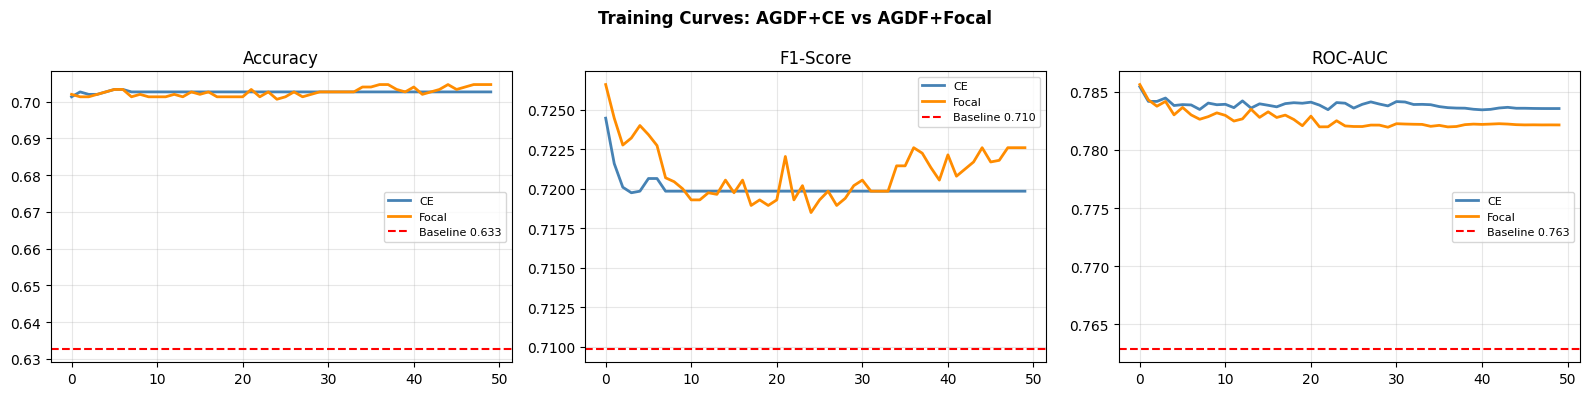

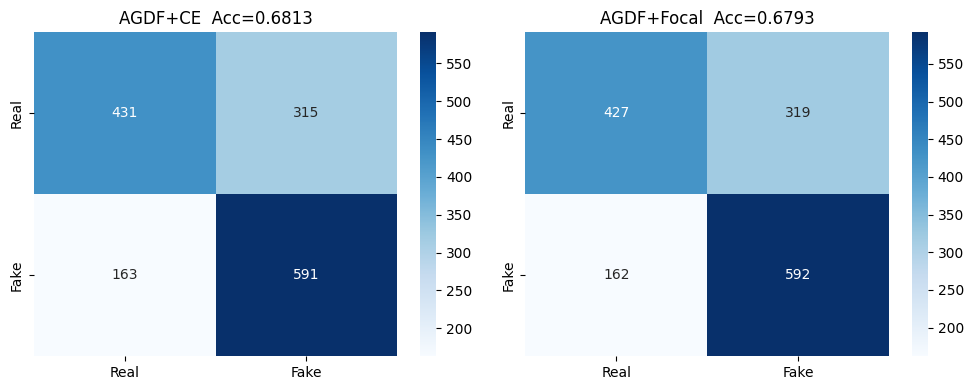

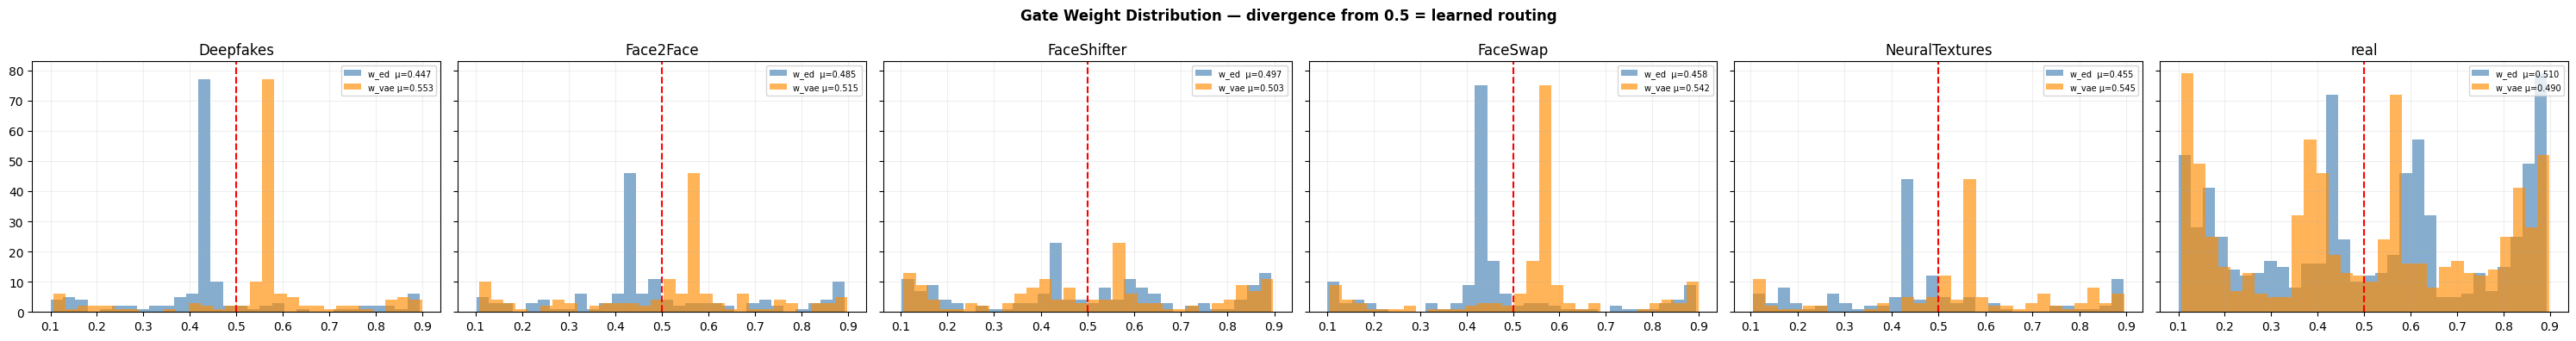


  Method                             Acc        F1       AUC
  Baseline (Static Avg)           0.6327    0.7098    0.7629
  AGDF+CE                         0.6813    0.7120    0.7654
  AGDF+Focal                      0.6793    0.7111    0.7606
--------------------------------------------------------------
  LODO Baseline                   0.5265    0.5208
  LODO AGDF+Focal                 0.6536    0.5634    0.7750


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix

# ── Training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Training Curves: AGDF+CE vs AGDF+Focal", fontweight="bold")
for ax, key, title, bl_val in zip(axes,
    ["val_acc","val_f1","val_auc"],
    ["Accuracy","F1-Score","ROC-AUC"],
    [bl_acc, bl_f1, bl_auc]):
    ax.plot(hist_ce[key], label="CE",    color="steelblue",  lw=2)
    ax.plot(hist_fl[key], label="Focal", color="darkorange", lw=2)
    ax.axhline(bl_val, color="red", ls="--", lw=1.5, label=f"Baseline {bl_val:.3f}")
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Confusion matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["labels"], r["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Real","Fake"], yticklabels=["Real","Fake"])
    ax.set_title(f"{name}  Acc={r['acc']:.4f}")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Weight distribution ───────────────────────────────────────────────────
r = results["AGDF+Focal"]
unique_m = [m for m in np.unique(r["manips"]) if m]
if unique_m:
    fig, axes = plt.subplots(1, len(unique_m), figsize=(5*len(unique_m), 4), sharey=True)
    if len(unique_m)==1: axes=[axes]
    fig.suptitle("Gate Weight Distribution — divergence from 0.5 = learned routing", fontweight="bold")
    for ax, manip in zip(axes, unique_m):
        mask = r["manips"] == manip
        ax.hist(r["w_ed"][mask],  bins=30, alpha=0.65, color="steelblue",
                label=f"w_ed  μ={r['w_ed'][mask].mean():.3f}")
        ax.hist(r["w_vae"][mask], bins=30, alpha=0.65, color="darkorange",
                label=f"w_vae μ={r['w_vae'][mask].mean():.3f}")
        ax.axvline(0.5, color="red", ls="--", lw=1.5)
        ax.set_title(manip); ax.legend(fontsize=7); ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/weight_dist.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Final summary table ───────────────────────────────────────────────────
print("\n" + "="*62)
print(f"  {'Method':<28}  {'Acc':>8}  {'F1':>8}  {'AUC':>8}")
print("="*62)
print(f"  {'Baseline (Static Avg)':<28}  {bl_acc:>8.4f}  {bl_f1:>8.4f}  {bl_auc:>8.4f}")
for name, r in results.items():
    print(f"  {name:<28}  {r['acc']:>8.4f}  {r['f1']:>8.4f}  {r['auc']:>8.4f}")
print("-"*62)
print(f"  {'LODO Baseline':<28}  {bl_lodo_acc:>8.4f}  {bl_lodo_f1:>8.4f}")
print(f"  {'LODO AGDF+Focal':<28}  {lodo_m['acc']:>8.4f}  {lodo_m['f1']:>8.4f}  {lodo_m['auc']:>8.4f}")
print("="*62)


In [18]:
import json

summary = {
    "baseline":     {"acc": float(bl_acc),  "f1": float(bl_f1),  "auc": float(bl_auc)},
    "agdf_ce":      {"acc": float(results["AGDF+CE"]["acc"]),
                     "f1":  float(results["AGDF+CE"]["f1"]),
                     "auc": float(results["AGDF+CE"]["auc"])},
    "agdf_focal":   {"acc": float(results["AGDF+Focal"]["acc"]),
                     "f1":  float(results["AGDF+Focal"]["f1"]),
                     "auc": float(results["AGDF+Focal"]["auc"])},
    "lodo_baseline":{"acc": float(bl_lodo_acc), "f1": float(bl_lodo_f1)},
    "lodo_agdf":    {"acc": float(lodo_m["acc"]),
                     "f1":  float(lodo_m["f1"]),
                     "auc": float(lodo_m["auc"])},
    "ood_recovery_acc": float(lodo_m["acc"] - bl_lodo_acc),
    "gamma_ablation": {str(g): {"acc": float(v["acc"]), "f1": float(v["f1"])}
                       for g, v in gamma_results.items()},
}
with open(f"{RESULTS_DIR}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("All outputs saved to /kaggle/working/results/")
print(json.dumps(summary, indent=2))


All outputs saved to /kaggle/working/results/
{
  "baseline": {
    "acc": 0.6326666666666667,
    "f1": 0.7098472880463402,
    "auc": 0.7628892555166015
  },
  "agdf_ce": {
    "acc": 0.6813333333333333,
    "f1": 0.7120481927710843,
    "auc": 0.7653559923482269
  },
  "agdf_focal": {
    "acc": 0.6793333333333333,
    "f1": 0.7111111111111111,
    "auc": 0.760567411695266
  },
  "lodo_baseline": {
    "acc": 0.5264886477224047,
    "f1": 0.5208092485549133
  },
  "lodo_agdf": {
    "acc": 0.6535770384121091,
    "f1": 0.5633549316054716,
    "auc": 0.7750141787319021
  },
  "ood_recovery_acc": 0.12708839068970446,
  "gamma_ablation": {
    "0.5": {
      "acc": 0.702,
      "f1": 0.7211478477854024
    },
    "1.0": {
      "acc": 0.7026666666666667,
      "f1": 0.7198492462311558
    },
    "2.0": {
      "acc": 0.706,
      "f1": 0.724202626641651
    },
    "3.0": {
      "acc": 0.702,
      "f1": 0.7218419415059116
    },
    "5.0": {
      "acc": 0.7026666666666667,
      "f1"